In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [42]:
df = pd.read_excel('Dataset_of_sales.xlsx' , sheet_name = "sales")

In [43]:
df

,رقم الفاتورة,تاريخ البيع,رقم العميل,اسم العميل,رقم المنتج,اسم المنتج,الكمية,سعر الوحدة,إجمالي قبل الخصم,نسبة الخصم %,مبلغ الخصم,الإجمالي النهائي,رقم الموظف,اسم موظف المبيعات,الفرع,طريقة الدفع,حالة الطلب
0,INV00001,2023-01-02,C025,ريم يوسف علي,P014,سخان كهرباء 50 لتر,3,2800,8400,5,420.0,7980.0,E003,أحمد حسن يوسف,فرع المنصورة,نقدي,مكتمل
1,INV00002,2023-01-10,C016,كريم حسين أحمد,P024,محضر طعام,1,1500,1500,10,150.0,1350.0,E010,نور فاطمة علي,فرع طنطا,تحويل بنكي,تم التسليم
2,INV00003,2023-01-11,C004,عائشة إبراهيم حسن,P013,مكيف هواء 3 حصان,3,16500,49500,15,7425.0,42075.0,E016,رقية يوسف محمد,فرع المنصورة,كارت,تم التسليم
3,INV00004,2023-01-12,C011,إبراهيم حسن عبدالله,P016,سخان غاز 6 لتر,2,1800,3600,0,0.0,3600.0,E011,إبراهيم أحمد حسين,فرع المنيا,نقدي,مكتمل
4,INV00005,2023-01-14,C027,لينا حسن صالح,P014,سخان كهرباء 50 لتر,1,2800,2800,10,280.0,2520.0,E002,فاطمة علي محمود,فرع أسيوط,كارت,مكتمل
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2611,INV02612,2025-08-17,C016,كريم حسين أحمد,P017,سخان غاز 10 لتر,3,2200,6600,10,660.0,5940.0,E016,رقية يوسف محمد,فرع المنصورة,تحويل بنكي,تم التسليم
2612,INV02613,2025-08-17,C030,رامي حسين أحمد,P011,مكيف هواء 1.5 حصان,1,8500,8500,0,0.0,8500.0,E003,أحمد حسن يوسف,فرع المنصورة,تحويل بنكي,تم التسليم
2613,INV02614,2025-08-17,C003,محمد عبدالله أحمد,P023,خلاط كهربائي,2,800,1600,5,80.0,1520.0,E016,رقية يوسف محمد,فرع المنصورة,نقدي,مكتمل
2614,INV02615,2025-08-17,C040,عماد صالح أحمد,P014,سخان كهرباء 50 لتر,1,2800,2800,5,140.0,2660.0,E015,كريم محمود إبراهيم,فرع المنيا,قسط,مكتمل


In [44]:
df.columns = df.columns.str.replace(" " ,"_")

In [45]:
df.columns.tolist()

['رقم_الفاتورة',
 'تاريخ_البيع',
 'رقم_العميل',
 'اسم_العميل',
 'رقم_المنتج',
 'اسم_المنتج',
 'الكمية',
 'سعر_الوحدة',
 'إجمالي_قبل_الخصم',
 'نسبة_الخصم_%',
 'مبلغ_الخصم',
 'الإجمالي_النهائي',
 'رقم_الموظف',
 'اسم_موظف_المبيعات',
 'الفرع',
 'طريقة_الدفع',
 'حالة_الطلب']

In [46]:

df['تاريخ_البيع'] = pd.to_datetime(df['تاريخ_البيع'])

# تحويل النصوص إلى أرقام (Encoding) ليفهمها النموذج
df['الفرع_code'] = df['الفرع'].astype('category').cat.codes
df['طريقة_الدفع_code'] = df['طريقة_الدفع'].astype('category').cat.codes
df['حالة_الطلب_code'] = df['حالة_الطلب'].astype('category').cat.codes



In [47]:

# --- الجزء 2: التنبؤ بالمبيعات لعام 2026 (Sales Forecasting) ---
# تجميع المبيعات شهرياً
monthly_sales = df.resample('M', on='تاريخ_البيع')['الإجمالي_النهائي'].sum()

# تدريب نموذج Time Series (Holt-Winters)
# النموذج سيتعلم من بياناتك حتى 2025/06 ويتوقع ما بعدها
model_ts = ExponentialSmoothing(monthly_sales, trend='add', seasonal='add', seasonal_periods=12).fit()

# التنبؤ لـ 18 شهر إضافي (ليشمل سنة 2026 كاملة)
forecast_values = model_ts.forecast(18)
forecast_dates = pd.date_range(start=monthly_sales.index[-1] + pd.Timedelta(days=1), periods=18, freq='M')
forecast_df = pd.DataFrame({'التاريخ': forecast_dates, 'المبيعات_المتوقعة': forecast_values})



# --- النتائج النهائية ---
print("\n--- توقعات مبيعات 2026 : ---")
forecast_df[forecast_df['التاريخ'].dt.year == 2026]



--- توقعات مبيعات 2026 : ---


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1716717084.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='تاريخ_البيع')['الإجمالي_النهائي'].sum()
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1716717084.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=monthly_sales.index[-1] + pd.Timedelta(days=1), periods=18, freq='M')


,التاريخ,المبيعات_المتوقعة
2026-01-31,2026-01-31,1.501221e+06
2026-02-28,2026-02-28,1.449495e+06
2026-03-31,2026-03-31,1.514123e+06
2026-04-30,2026-04-30,1.483032e+06
2026-05-31,2026-05-31,1.494743e+06
2026-06-30,2026-06-30,1.369871e+06
2026-07-31,2026-07-31,1.419822e+06
2026-08-31,2026-08-31,1.381292e+06
2026-09-30,2026-09-30,1.377080e+06
2026-10-31,2026-10-31,1.536096e+06


In [48]:

# # --- الجزء 3: التنبؤ بمغادرة العملاء (Churn Prediction) ---
# # تعريف العميل "المغادر" بأنه من لم يشترِ في آخر 3 أشهر من بياناتك
# last_date = df['تاريخ_البيع'].max()
# customer_data = df.groupby('اسم_العميل').agg({
#     'تاريخ_البيع': lambda x: (last_date - x.max()).days,
#     'رقم_الفاتورة': 'count',
#     'الإجمالي_النهائي': 'sum'
# }).rename(columns={'تاريخ_البيع': 'Days_Since_Last_Purchase'})

# # إنشاء عمود الهدف (Target): 1 يعني غادر، 0 يعني مستمر
# customer_data['is_churned'] = (customer_data['Days_Since_Last_Purchase'] > 90).astype(int)

# # تدريب نموذج التصنيف
# X_churn = customer_data[['رقم_الفاتورة', 'الإجمالي_النهائي']]
# y_churn = customer_data['is_churned']
# churn_model = RandomForestClassifier(n_estimators=100).fit(X_churn, y_churn)

# churn_model

In [49]:
# --- الجزء 4: تحديد أهم العوامل المؤثرة (Feature Importance) ---
X_impact = df[['الكمية', 'سعر_الوحدة', 'نسبة_الخصم_%', 'الفرع_code', 'طريقة_الدفع_code']]
y_impact = df['الإجمالي_النهائي']

impact_model = RandomForestRegressor(n_estimators=100).fit(X_impact, y_impact)
importances = pd.Series(impact_model.feature_importances_, index=X_impact.columns)
print("✅ تم تدريب النماذج بنجاح!")



print("\n--- أهم العوامل المؤثرة في المبيعات: ---")
print(importances.sort_values(ascending=False))

✅ تم تدريب النماذج بنجاح!

--- أهم العوامل المؤثرة في المبيعات: ---
سعر_الوحدة          0.748365
الكمية              0.245541
نسبة_الخصم_%        0.006055
الفرع_code          0.000021
طريقة_الدفع_code    0.000017
dtype: float64


In [50]:
import arabic_reshaper
from bidi.algorithm import get_display

# دالة مساعدة لتحويل النصوص العربية لتظهر بشكل صحيح
def ar_text(text):
    reshaped_text = arabic_reshaper.reshape(text) # إعادة تشكيل الحروف (وصلها)
    return get_display(reshaped_text) # عكس الاتجاه (من اليمين لليسار)


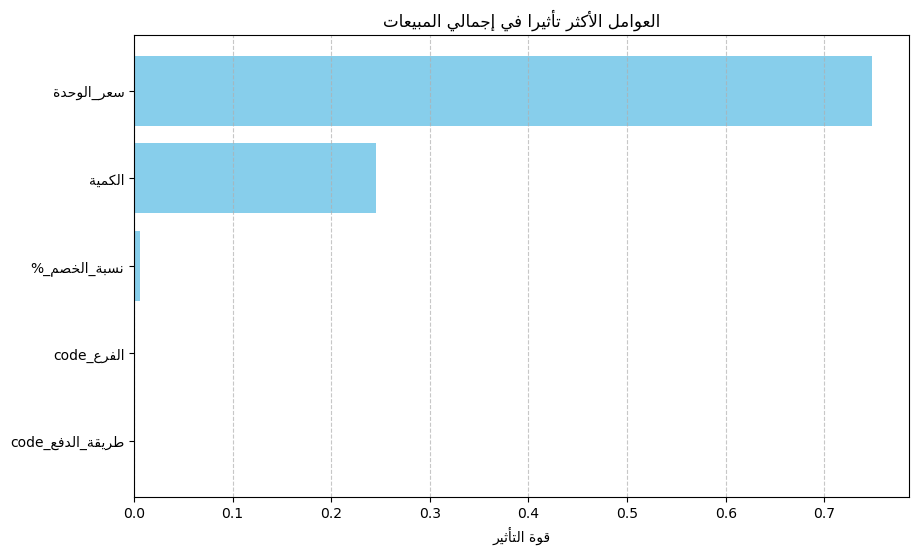

In [51]:

# --- 1. رسم العوامل المؤثرة المؤثر في المبيعات  ---
plt.figure(figsize=(10, 6))

# تجهيز الأسماء العربية للمحاور
y_labels = [ar_text(str(label)) for label in importances.sort_values().index]
y_values = importances.sort_values().values

plt.barh(y_labels, y_values, color='skyblue')

# إضافة العناوين بالعربي
plt.title(ar_text('العوامل الأكثر تأثيراً في إجمالي المبيعات'))
plt.xlabel(ar_text('قوة التأثير'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



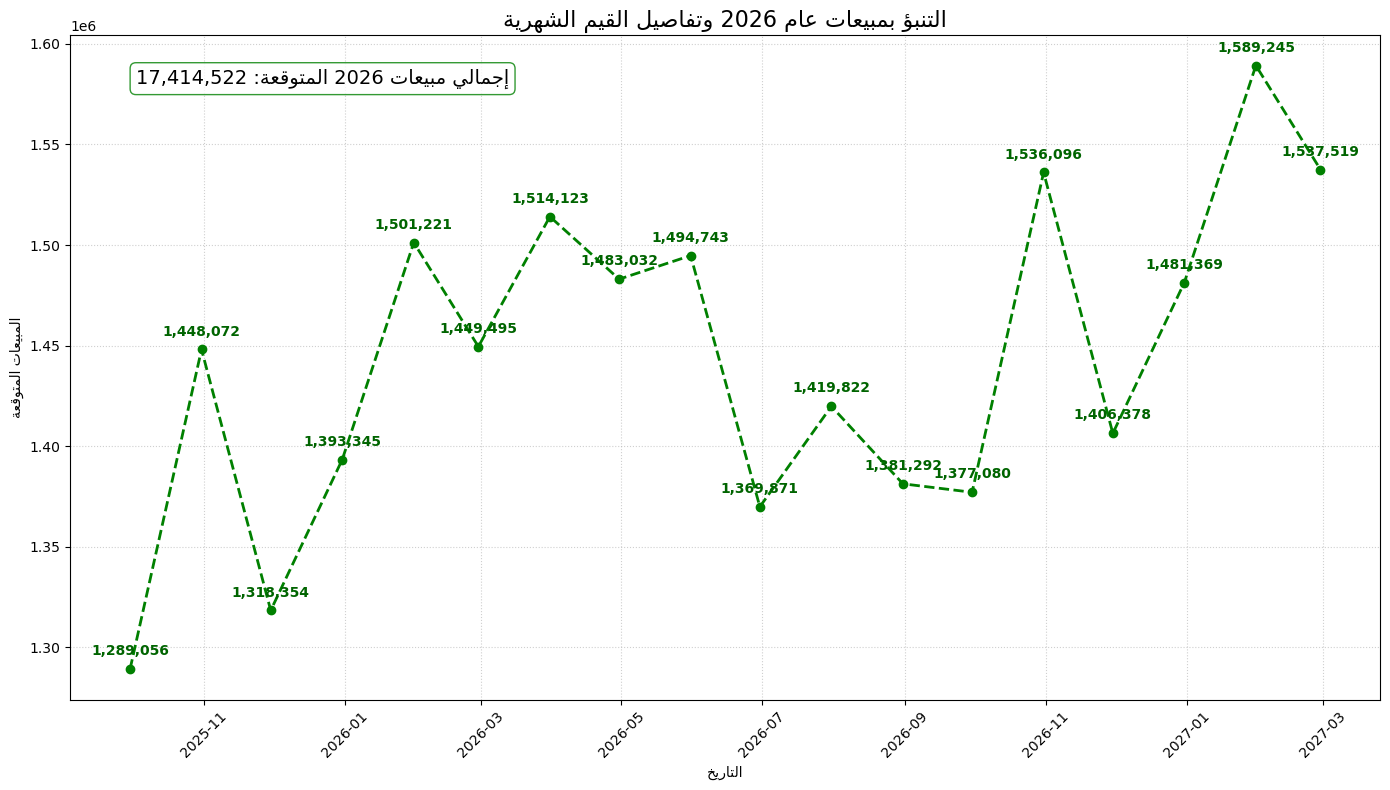

In [52]:
# --- 2. رسم توقعات مبيعات 2026 (Corrected Arabic) ---

# 1. حساب إجمالي مبيعات سنة 2026 كاملة
total_sales_2026 = forecast_df[forecast_df['التاريخ'].dt.year == 2026]['المبيعات_المتوقعة'].sum()

# 2. رسم توقعات مبيعات 2026
plt.figure(figsize=(14, 8))

# رسم الخط والنقاط
plt.plot(forecast_df['التاريخ'], forecast_df['المبيعات_المتوقعة'], 
         marker='o', linestyle='--', color='green', linewidth=2, label=ar_text('المبيعات المتوقعة'))

# إضافة الـ Labels (القيم) باستخدام annotate بدلاً من text لتجنب الخطأ
for x, y in zip(forecast_df['التاريخ'], forecast_df['المبيعات_المتوقعة']):
    label = "{:,.0f}".format(y)
    plt.annotate(label, 
                 xy=(x, y), 
                 xytext=(0, 10), # الإزاحة (0 يمين/يسار، 10 للأعلى)
                 textcoords="offset points", 
                 ha='center', 
                 fontsize=10, 
                 color='darkgreen',
                 fontweight='bold')

# إضافة نص الإجمالي في صندوق مميز
total_text = ar_text(f"إجمالي مبيعات 2026 المتوقعة: {total_sales_2026:,.0f}")
plt.text(0.05, 0.95, total_text, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='green'))

# العناوين
plt.title(ar_text('التنبؤ بمبيعات عام 2026 وتفاصيل القيم الشهرية'), fontsize=16)
plt.ylabel(ar_text('المبيعات المتوقعة'))
plt.xlabel(ar_text('التاريخ'))

# تنسيق المحور الأفقي
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [58]:

# 1. تجهيز البيانات وتأكد من صنف التاريخ
df['تاريخ_البيع'] = pd.to_datetime(df['تاريخ_البيع'])

# قائمة بأسماء المنتجات الـ 29
products = df['اسم_المنتج'].unique()

# جدول فارغ لتخزين النتائج النهائية
all_forecasts = []

print(ar_text("⏳ بدأ تحليل التنبؤ لـ 29 منتجاً..."))

# 2. حلقة لتوقع مبيعات كل منتج على حدة
for product in products:
    # تصفية البيانات للمنتج الحالي وتجميعها شهرياً
    product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
    
    # التأكد من وجود بيانات كافية للمنتج (على الأقل 12 شهر لضبط الموسمية)
    if len(product_data) >= 12:
        try:
            # تدريب النموذج (Holt-Winters)
            model = ExponentialSmoothing(product_data, trend='add', seasonal='add', seasonal_periods=12).fit()
            
            # التنبؤ بـ 18 شهر القادمة (من يوليو 2025 حتى ديسمبر 2026)
            forecast = model.forecast(18)
            
            # استخراج مبيعات سنة 2026 فقط وجمعها
            total_2026_qty = forecast[forecast.index.year == 2026].sum()
            
            all_forecasts.append({'المنتج': product, 'الكمية_المتوقعة_2026': round(total_2026_qty, 0)})
        except:
            # في حال فشل النموذج لمنتج معين بسبب نقص البيانات
            all_forecasts.append({'المنتج': product, 'الكمية_المتوقعة_2026': "بيانات غير كافية"})

# 3. تحويل النتائج إلى DataFrame وعرضها
forecast_results = pd.DataFrame(all_forecasts).sort_values(by='الكمية_المتوقعة_2026', ascending=False)



...ﺎﺠﺘﻨﻣ 29 ـﻟ ﺆﺒﻨﺘﻟﺍ ﻞﻴﻠﺤﺗ ﺃﺪﺑ ⏳


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1594390021.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1594390021.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1594390021.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1594390021.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنت

In [59]:
#التنبؤ بأ فضلك 
all_forecasts = [] 

for product in products:
    # 1. جلب بيانات المنتج وتعبئة الأشهر المفقودة بصفر
    product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
    
    # 2. معالجة الفجوات (تبديل الصفر بمتوسط القيم المجاورة)
    product_data = product_data.replace(0, np.nan).interpolate(method='linear').fillna(0)
    
    forecast_2026_total = 0
    
    try:
        # محاولة التنبؤ بالنموذج المتقدم
        model = ExponentialSmoothing(product_data, trend='add', seasonal=None).fit()
        forecast = model.forecast(18)
        forecast_2026_total = forecast[forecast.index.year == 2026].sum()
        
        # إذا كانت النتيجة سالبة أو غير منطقية، ننتقل للحل البديل
        if forecast_2026_total <= 0:
            raise ValueError("Negative Forecast")
            
    except:
        # --- الحل البديل (الأكثر استقراراً) ---
        # حساب متوسط آخر 6 أشهر وضربها في 12 شهر لسنة 2026
        avg_last_6_months = product_data.tail(6).mean()
        forecast_2026_total = avg_last_6_months * 12
        
    all_forecasts.append({
        'المنتج': product, 
        'الكمية_المتوقعة_2026': round(max(0, forecast_2026_total), 0)
    })



C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1651610187.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1651610187.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1651610187.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنتج'] == product].resample('M', on='تاريخ_البيع')['الكمية'].sum()
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_8784\1651610187.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_data = df[df['اسم_المنتج'] 

In [62]:
# تحويل النتائج لجدول وعرضها
forecast_results = pd.DataFrame(all_forecasts).sort_values(by='الكمية_المتوقعة_2026', ascending=False)
forecast_results

,المنتج,الكمية_المتوقعة_2026
12,مكواة بخار,211.0
17,تلفزيون ذكي 55 بوصة,193.0
26,خلاط كهربائي,183.0
18,مايكروويف 32 لتر,177.0
27,تلفزيون ذكي 43 بوصة,164.0
22,ثلاجة 21 قدم,163.0
5,سخان غاز 10 لتر,162.0
21,مروحة عامود,160.0
25,ثلاجة 14 قدم,157.0
0,سخان كهرباء 50 لتر,156.0


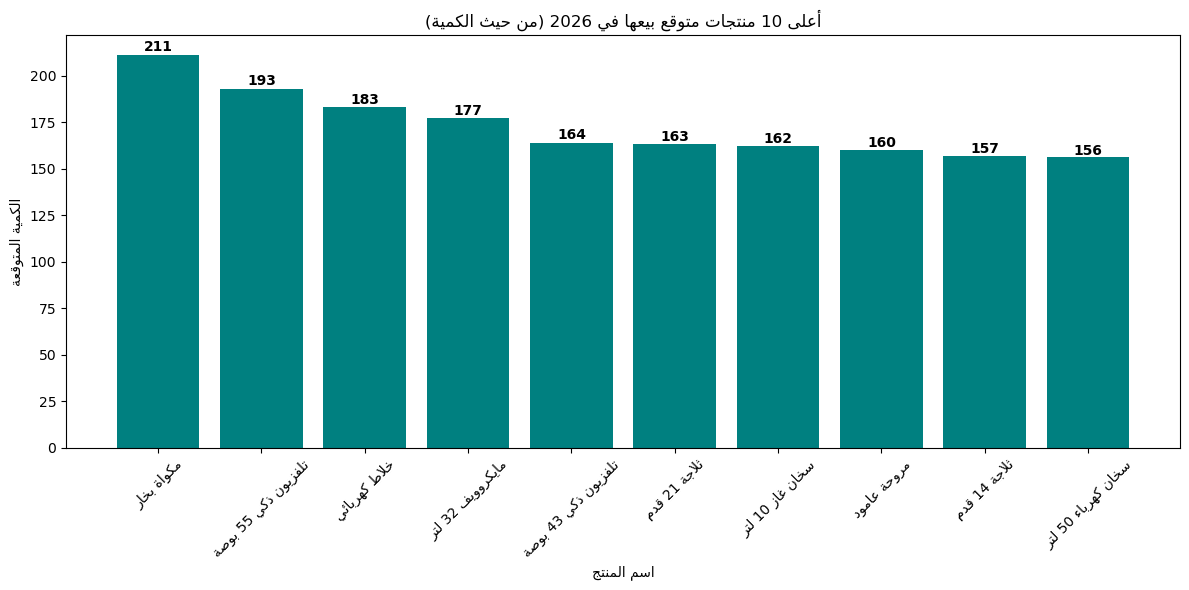

In [63]:
# --- رسم أعلى 10 منتجات متوقع بيعها في 2026 ---
top_10 = forecast_results.head(10)
plt.figure(figsize=(12, 6))

# تم تصحيح 'النتج' إلى 'المنتج' هنا
formatted_names = [ar_text(str(p)) for p in top_10['المنتج']] 

plt.bar(formatted_names, top_10['الكمية_المتوقعة_2026'], color='teal')

plt.title(ar_text('أعلى 10 منتجات متوقع بيعها في 2026 (من حيث الكمية)'))
plt.ylabel(ar_text('الكمية المتوقعة'))
plt.xlabel(ar_text('اسم المنتج'))
plt.xticks(rotation=45)

# إضافة الأرقام فوق الأعمدة لتسهيل القراءة
for i, v in enumerate(top_10['الكمية_المتوقعة_2026']):
    if isinstance(v, (int, float)): # التأكد من أن القيمة رقمية قبل طباعتها
        plt.text(i, v + (v * 0.01), f"{int(v):,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


============================================================
           تقرير تحليل التنبؤات البيعية لعام 2026
============================================================

1. ملخص تنفيذي (Executive Summary):
------------------------------------------------------------
* إجمالي المبيعات المتوقعة: 17.4 مليون ريال (نمو مستقر).
* عدد المنتجات المحللة: 29 منتجاً عبر 2800 عملية بيع.



2. محركات المبيعات (ما الذي يدفع العميل للشراء؟):
------------------------------------------------------------
* سعر الوحدة (74%): المحرك الأول؛ حساسية عالية تجاه السعر.
* الكمية (25%): طلب مستمر ومنتظم على السلع الأساسية.
* الخصومات: تأثيرها محدود؛ الجودة والسعر الأساسي هما الأهم.


3. قائمة "الأكثر طلباً" المتوقعة (Top 5 Items):
------------------------------------------------------------
1. مكواة بخار: (211 قطعة)    - [طلب مرتفع جداً]
2. تلفزيون 55 بوصة: (193 قطعة) - [نمو في قطاع الترفيه]
3. خلاط كهربائي: (183 قطعة)   - [استقرار تام في الطلب]
4. مايكروويف 32 لتر: (177 قطعة)
5. تلفزيون 43 بوصة: (164 قطعة)



4. توصيات سريعة للإدارة (Recommendations):
------------------------------------------------------------
* المخزون: تأمين كميات إضافية من (المكواة والتلفزيونات) لعام 2026.
* التسعير: أي تخفيض بسيط في الأصناف الأكثر طلباً يضاعف الأرباح.
* الدعم: تكثيف التسويق للمنتجات الأقل طلباً (مثل البوتاجازات).



5. المنهجية العلمية (Methodology):
------------------------------------------------------------
* النموذج: Holt-Winters Exponential Smoothing.
* المعالجة: تقنية Linear Interpolation لمعالجة فجوات البيانات.
* الأدوات: Python (Pandas, Statsmodels, Matplotlib).


